#Study of S&P 500 Index after Covid-19

**Problem Statement:** We investigate the effects of the coronavirus disease 2019 (COVID-19) cases
in the U.S. on the S&P 500 Index using daily data covering the period between March 1st, 2020 and April 29th, 2022. And then try to predict some closing values using historical data.

Historical decomposition of the S&P 500 Index suggests that the negative effects of
COVID-19 cases on the S&P 500 Index have been mostly observed during
March 2020.

**Stationarity:** Time series data that is used for statistical analysis is stationary in order to perform statistical modeling correctly, as such usages may be for prediction and forecasting. Otherwise, modeling from non-stationary data may produce unpredictable results. A stationary time series is one whose statistical properties, such as mean, variance, and autocorrelation, are constant over time.

**Checking for stationarity:** We used `Augmented Dickey-Fuller Test` to check if stationarity expectations have been met or violated.

**Forecasting and predicting a time series** We identified non-stationarity in time series data and made the data stationary. With stationary data, we can proceed to perform statistical modeling such as prediction and forecasting. Prediction involves generating best estimates of in-sample data. Forecasting involves generating best estimates of out-of-sample data. Predicting future values is based on previously observed values. One such commonly used method is the Autoregressive Integrated Moving Average(ARIMA). We then plot the predicted and forecasted prices against our original dataset, from 2020 onwards.


**Dataset:** We have used `yfinance` package to import our `S&P` data.

In [1]:
!pip install yfinance
!pip install pandas==1.1.3

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.2/5.2 MB 17.9 MB/s eta 0:00:00
  error: subprocess-exited-with-error
  
  × pip subprocess to install build dependencies did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Installing build dependencies ... error
error: subprocess-exited-with-error

× pip subprocess to install build dependencies did not run successfully.
│ exit code: 1
╰─> See above for output.

note: This error originates from a subprocess, and is likely not a problem with pip.


In [2]:
!pip install statsmodels==0.11.0

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.4/15.4 MB 52.8 MB/s eta 0:00:00
  error: subprocess-exited-with-error
  
  × pip subprocess to install build dependencies did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Installing build dependencies ... error
error: subprocess-exited-with-error

× pip subprocess to install build dependencies did not run successfully.
│ exit code: 1
╰─> See above for output.

note: This error originates from a subprocess, and is likely not a problem with pip.


**Dataset:** We have used `yfinance` package to import our s&p data.

In [32]:
import pandas as pd
import numpy as np
import yfinance as yahooFinance

import matplotlib.pyplot as plt

import datetime

# startDate , as per our convenience we can modify
startDate = datetime.datetime(2020, 3, 1)
endDate = datetime.datetime(2025, 3, 28)

GetsnpInformation = yahooFinance.Ticker("QQQ")

# pass the parameters as the taken dates for start and end
df = GetsnpInformation.history(start=startDate, end= endDate)

In [33]:
df.tail()

,Open,High,Low,Close,Volume,Dividends,Stock Splits,Capital Gains
Date,,,,,,,,
2025-03-21 00:00:00-04:00,473.374049,480.892835,472.205809,480.123993,42234900,0.000,0.0,0.0
2025-03-24 00:00:00-04:00,487.739990,491.510010,484.399994,490.660004,34567200,0.716,0.0,0.0
2025-03-25 00:00:00-04:00,491.390015,493.619995,490.420013,493.459991,26035200,0.000,0.0,0.0
2025-03-26 00:00:00-04:00,492.299988,493.160004,482.820007,484.380005,34627100,0.000,0.0,0.0
2025-03-27 00:00:00-04:00,482.410004,486.579987,480.250000,481.619995,33469800,0.000,0.0,0.0


In [34]:
dfnew = df.drop(columns = ['Dividends', 'Stock Splits'])
dfnew.head()

,Open,High,Low,Close,Volume,Capital Gains
Date,,,,,,
2020-03-02 00:00:00-05:00,202.276058,209.722934,199.429007,209.577667,112933900,0.0
2020-03-03 00:00:00-05:00,210.245845,212.666805,201.055876,202.857071,131953500,0.0
2020-03-04 00:00:00-05:00,206.575679,211.427278,204.687319,211.320755,73086200,0.0
2020-03-05 00:00:00-05:00,205.965604,209.519571,203.457493,204.900375,78705500,0.0
2020-03-06 00:00:00-05:00,198.199190,202.537547,196.494839,201.443283,89828400,0.0


Plotting the data

<Axes: xlabel='Date'>

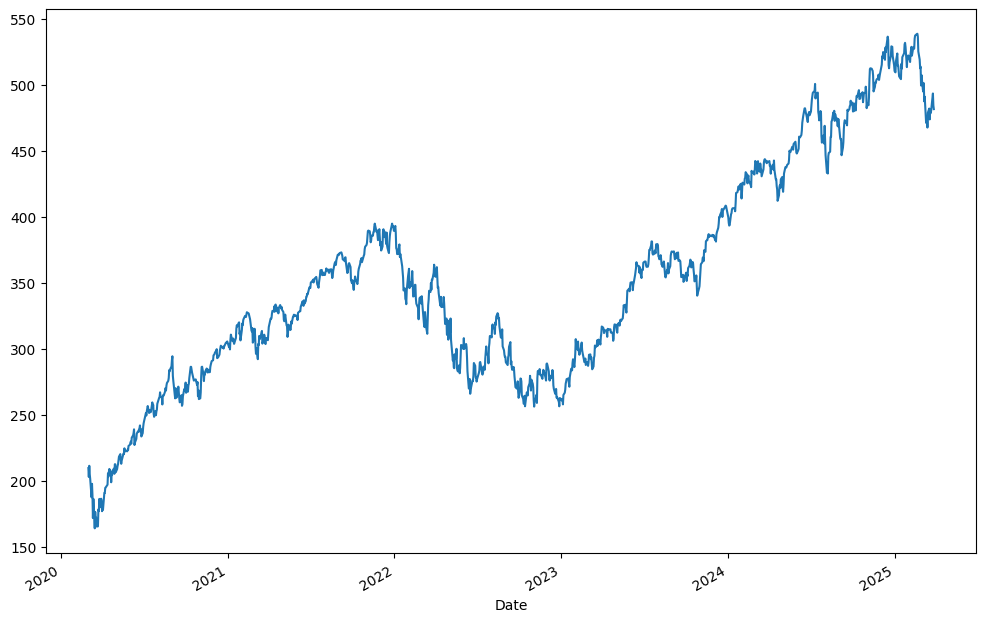

In [35]:
dfnew['Close'].plot(figsize=(12, 8))
# xcoords = ['2020-04-01', '2020-07-01','2020-10-01', '2021-01-01', '2021-04-01', '2021-07-01',
#           '2021-10-01','2022-01-01','2022-04-01']
# for xc in xcoords:
#     plt.axvline(x=xc, color='black', linestyle='--')

Trend and Seasonality check


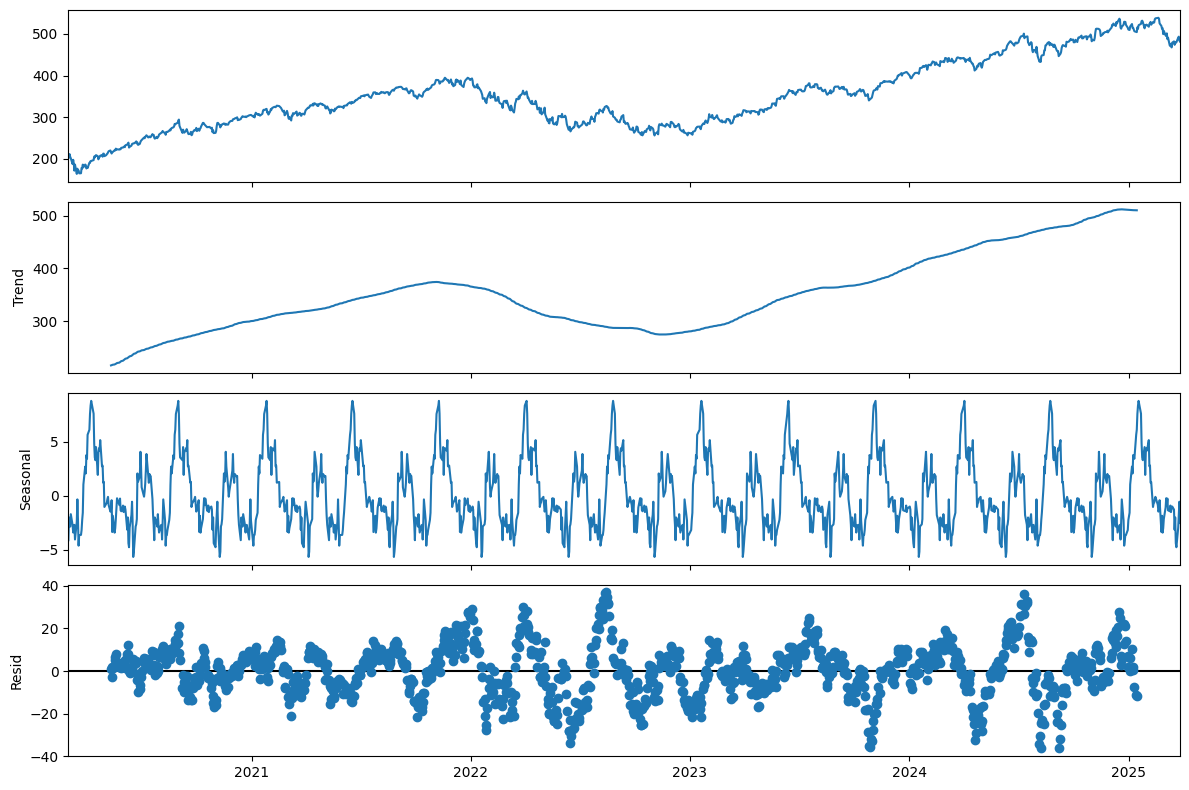

In [36]:
from statsmodels.tsa.seasonal import seasonal_decompose

analysis = dfnew[['Close']].copy()
#analysis = dfnew['Close'].resample('MS').

analysis.index = pd.to_datetime(dfnew.index)

decompose_result_mult = seasonal_decompose(analysis, model="additive", period =100)

trend = decompose_result_mult.trend
seasonal = decompose_result_mult.seasonal
residual = decompose_result_mult.resid

plt.rcParams["figure.figsize"] = (12, 8)
fig = decompose_result_mult.plot()

Confirming the Seasonality with Periodogram

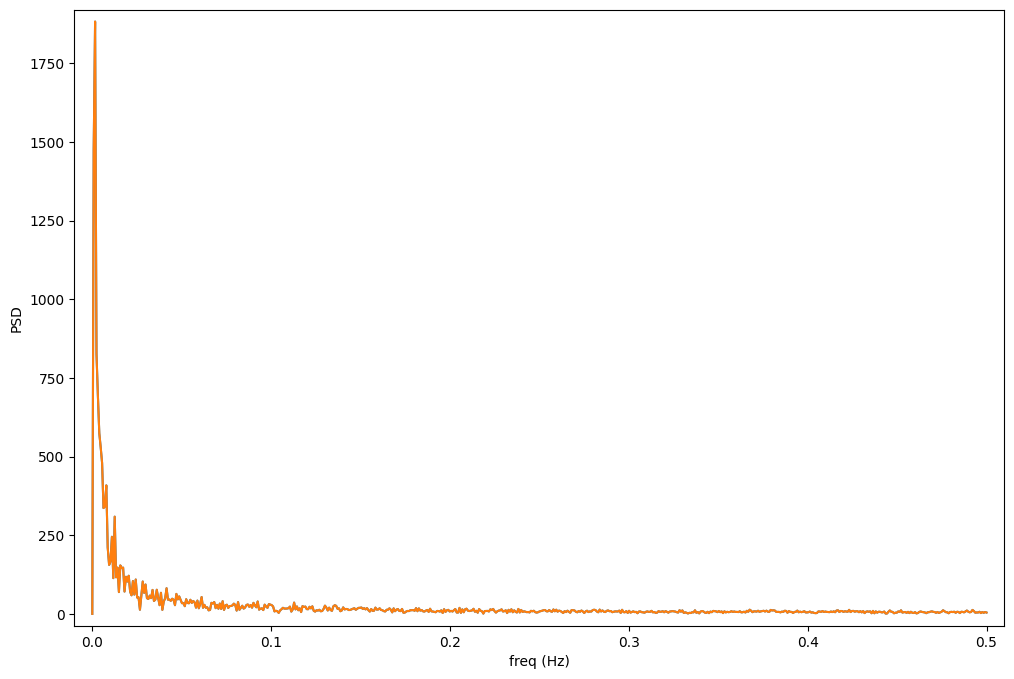

In [37]:
import scipy
# Determine frequencies
# f = np.fft.fftfreq(len(dfnew)) * sampling_freq

# # Compute power spectral density
# psd = np.abs(np.fft.fft(dfnew.values))**2 / len(dfnew)

f, psd = scipy.signal.periodogram(analysis['Close'])
# Make plot
plt.plot(f, np.sqrt(psd))
plt.xlabel('freq (Hz)')
plt.ylabel('PSD')
plt.margins(0.02)
plt.rcParams["figure.figsize"] = (25, 8)
fig = plt.plot(f, np.sqrt(psd))

Stationarity Cheack on raw data

In [38]:
from statsmodels.tsa.stattools import adfuller

x = analysis.dropna()
dftest = adfuller(x)

print("1. ADF : ",dftest[0])
print("2. P-Value : ", dftest[1])
print("3. Num Of Lags : ", dftest[2])
print("4. Num Of Observations Used For ADF Regression and Critical Values Calculation :", dftest[3])
print("5. Critical Values :")
for key, val in dftest[4].items():
    print("\t",key, ": ", val)

1. ADF :  -1.1764075418813773
2. P-Value :  0.6836613767226589
3. Num Of Lags :  0
4. Num Of Observations Used For ADF Regression and Critical Values Calculation : 1275
5. Critical Values :
	 1% :  -3.4354892269437243
	 5% :  -2.863809525815561
	 10% :  -2.5679783161860823


Log Transformation: We perform detrending on the same dataset with logarithmic transformation and subtracting from the moving average of two periods, as given

<Axes: title={'center': 'Original Values'}, xlabel='Date'>

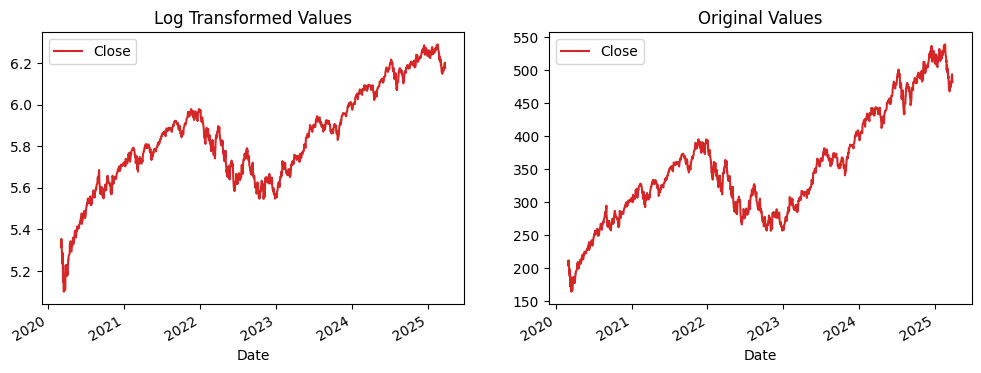

In [39]:
logged_closevalues = analysis.apply(lambda x : np.log(x))
ax1 = plt.subplot(121)
logged_closevalues.plot(figsize=(12,4) ,color="tab:red", title="Log Transformed Values", ax=ax1)
ax2 = plt.subplot(122)
analysis.plot(color="tab:red", title="Original Values", ax=ax2)

Dicky fuller test after log transformation. The p-value for this detrended data is less than 0.05. Our ADF test statistic is lower than all the critical values. We can reject the null hypothesis and say that this data is stationary.

In [40]:
from statsmodels.tsa.stattools import adfuller

x = logged_closevalues.dropna()
dftest = adfuller(x)

print("1. ADF : ",dftest[0])
print("2. P-Value : ", dftest[1])
print("3. Num Of Lags : ", dftest[2])
print("4. Num Of Observations Used For ADF Regression and Critical Values Calculation :", dftest[3])
print("5. Critical Values :")
for key, val in dftest[4].items():
    print("\t",key, ": ", val)

1. ADF :  -2.2992198910864143
2. P-Value :  0.1722196956092517
3. Num Of Lags :  18
4. Num Of Observations Used For ADF Regression and Critical Values Calculation : 1257
5. Critical Values :
	 1% :  -3.4355629707955395
	 5% :  -2.863842063387667
	 10% :  -2.567995644141416


Removing the trend using Moving Window Function on Log Transformed Time-Series

We Compute the rolling mean and standard deviation into the df_mean and df_std variables, respectively, with a window period of one year.

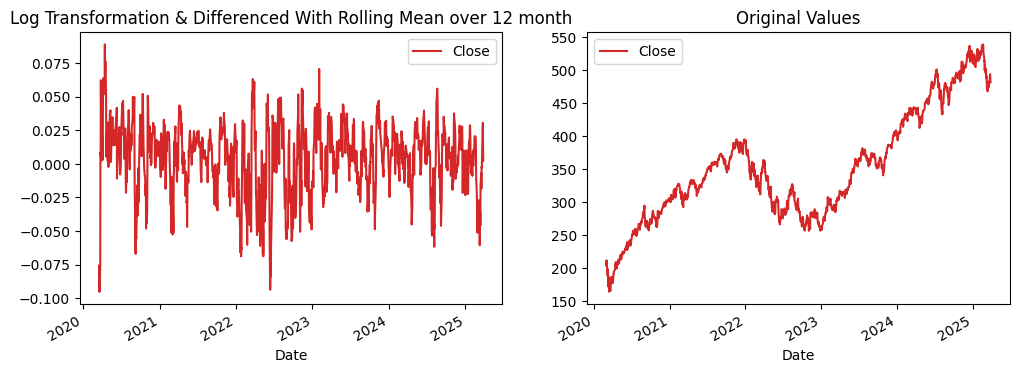

In [41]:
rolling_mean = logged_closevalues.rolling(window = 12).mean()
price_log_rolled_detrended = logged_closevalues - rolling_mean

ax1 = plt.subplot(121)
price_log_rolled_detrended.plot(figsize=(12,4),color="tab:red", title="Log Transformation & Differenced With Rolling Mean over 12 month", ax=ax1);
ax2 = plt.subplot(122)
analysis.plot(figsize=(12,4), color="tab:red", title="Original Values", ax=ax2);

Seasonal decomposing: Decomposing involves modeling both the trend and seasonality, and then removing them. We can use the statsmodel.tsa.seasonal module to model a non-stationary time series dataset using moving averages and remove its trend and seasonal components.

The individual trend and seasonality components being removed from the dataset and plotted, and the residuals plotted at the bottom.

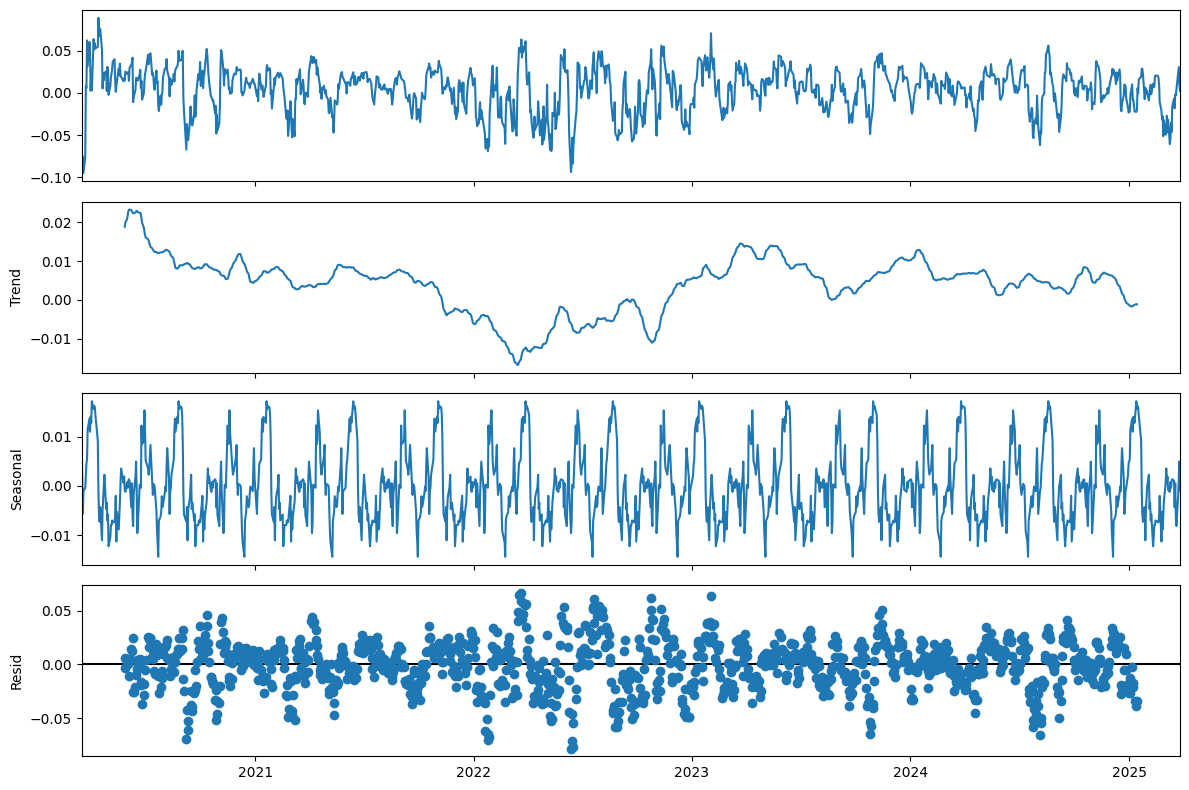

In [42]:
decompose_result = seasonal_decompose(price_log_rolled_detrended.dropna(), model="additive", period=100)

trend = decompose_result.trend
seasonal = decompose_result.seasonal
residual = decompose_result.resid

plt.rcParams["figure.figsize"] = (12, 8)
fig = decompose_result.plot()

In [43]:
price_log_rolled_detrended = price_log_rolled_detrended.dropna()
price_log_rolled_detrended

,Close
Date,
2020-03-17 00:00:00-04:00,-0.081202
2020-03-18 00:00:00-04:00,-0.095146
2020-03-19 00:00:00-04:00,-0.075432
2020-03-20 00:00:00-04:00,-0.094929
2020-03-23 00:00:00-04:00,-0.076373
...,...
2025-03-21 00:00:00-04:00,0.004005
2025-03-24 00:00:00-04:00,0.025169
2025-03-25 00:00:00-04:00,0.030453


**Grid search for model parameters:** A grid search, also known as the hyperparameter optimization method, can be used to iteratively explore different combinations of parameters for fitting our ARIMA model. We can fit a seasonal ARIMA model with the `SARIMAX()` function of the statsmodels module.

The model with the lowest AIC value gives us the best-fitting model that determines our parameters of p, d, and q.

ARIMA(1, 0, 0)x(1, 0, 1, 12) seasonal component model would give us the lowest AIC value. We shall use these parameters to fit our SARIMAX model.


In [44]:
import itertools
import warnings
from statsmodels.tsa.statespace.sarimax import SARIMAX

warnings.filterwarnings("ignore")

def arima_grid_search(dataframe, s):
    p = d = q = range(2)
    param_combinations = list(itertools.product(p, d, q))

    lowest_aic, pdq, pdqs = None, None, None

    total_iterations = 0
    for order in param_combinations:
        for (p, q, d) in param_combinations:
            seasonal_order = (p, q, d, s)
            total_iterations += 1
            #print(seasonal_order)
            try:
                #print('yayyy')
                model = SARIMAX(price_log_rolled_detrended, order=order,
                    seasonal_order=seasonal_order,
                    enforce_stationarity=False,
                    enforce_invertibility=False,
                    disp=False
                )
                model_result = model.fit(maxiter=200, disp=False)
                #print(model_result)
                if not lowest_aic or model_result.aic < lowest_aic:
                    lowest_aic = model_result.aic
                    pdq, pdqs = order, seasonal_order
                    print(lowest_aic, pdq, pdqs)

            except Exception as ex:
                continue

    return lowest_aic, pdq, pdqs

In [45]:
lowest_aic, order, seasonal_order = arima_grid_search(price_log_rolled_detrended, 12)

-5633.327011903879 (0, 0, 0) (0, 0, 0, 12)
-6513.456601350563 (0, 0, 1) (0, 0, 0, 12)
-6518.3871960169245 (0, 0, 1) (1, 0, 0, 12)
-7156.130808942252 (0, 1, 0) (0, 0, 0, 12)
-7159.461908099849 (0, 1, 0) (0, 0, 1, 12)
-7162.983756004742 (0, 1, 0) (1, 0, 0, 12)
-7164.297320035792 (0, 1, 0) (1, 0, 1, 12)
-7172.57951018721 (0, 1, 1) (0, 0, 1, 12)
-7173.342828515601 (0, 1, 1) (1, 0, 1, 12)
-7262.3483404838 (1, 0, 0) (0, 0, 0, 12)
-7264.2784830975015 (1, 0, 0) (1, 0, 1, 12)


In [46]:
print('ARIMA{}x{}'.format(order, seasonal_order))
print('Lowest AIC: %.3f'%lowest_aic)

ARIMA(1, 0, 0)x(1, 0, 1, 12)
Lowest AIC: -7264.278


Fitting the SARIMAX model: Having obtained the optimal model parameters, inspect the model properties using the summary() method on the fitted results to view detailed statistical information. We then run model diagnostics to investigate that model assumptions haven't been violated:


In [47]:
model = SARIMAX(
    analysis,
    order=order,
    seasonal_order=seasonal_order,
    enforce_stationarity=True,
    enforce_invertibility=False,
    disp=False
)

model_results = model.fit(maxiter=200, disp=False)

In [48]:
print(model_results.summary())

                                      SARIMAX Results                                       
Dep. Variable:                                Close   No. Observations:                 1276
Model:             SARIMAX(1, 0, 0)x(1, 0, [1], 12)   Log Likelihood               -3872.851
Date:                              Fri, 11 Apr 2025   AIC                           7753.701
Time:                                      17:03:26   BIC                           7774.307
Sample:                                           0   HQIC                          7761.440
                                             - 1276                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9996      0.001   1566.898      0.000       0.998       1.001
ar.S.L12       0.99

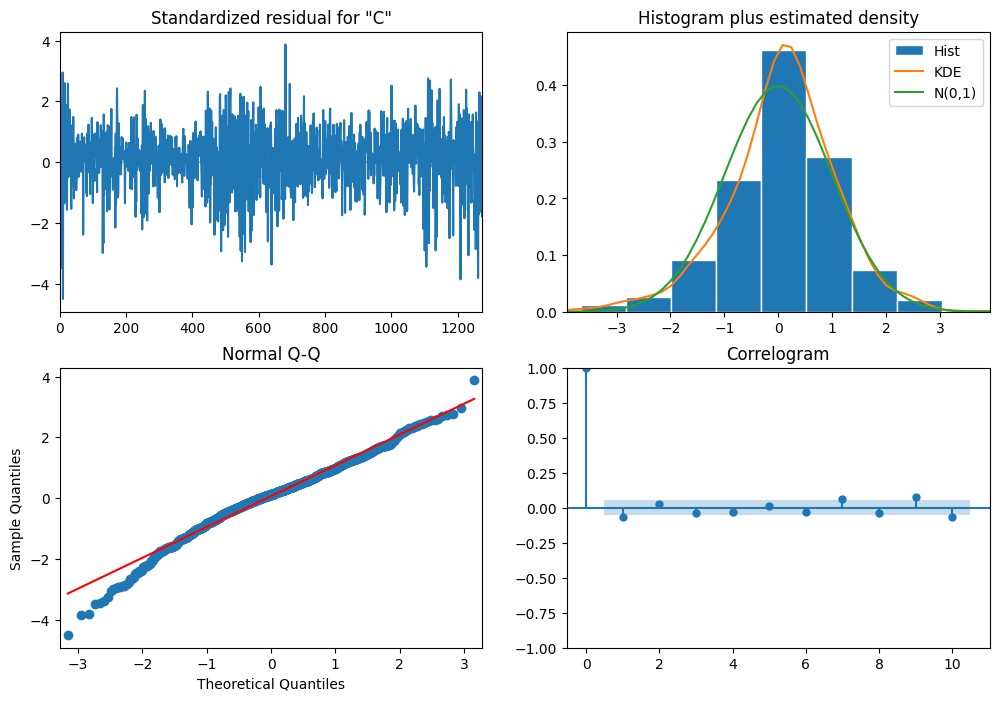

In [49]:
model_results.plot_diagnostics(figsize=(12, 8));

The top-right plot shows the kernel density estimate (KDE) of the standardized residuals, which suggests the errors are Gaussian with a mean close to zero.

Here, the non zero mean suggests that prediction may be biased positively

In [50]:
model_results.resid.describe()

,0
count,1276.000000
mean,0.470226
std,7.707780
min,-22.269825
25%,-2.271892
50%,0.589686
75%,3.328783
max,209.577667


Predicting and Forecasting the Model: The model_results variable is a SARIMAXResults object of the statsmodel module, representing the output of the SARIMAX model. It contains a get_prediction() method for performing in-sample prediction and out-of-sample forecasting. It also contains a conf_int() method, which returns the confidence intervals of the predictions, both lower- and upper-bounded, of the fitted parameters, which is at a 95% confidence interval by default.

In [61]:
prediction = model_results.get_prediction(
    start='2024-04-01',
    end='2025-03-27'

)
prediction_ci = prediction.conf_int()

In [53]:
print(prediction.summary_frame())

Close                            mean   mean_se  mean_ci_lower  mean_ci_upper
Date                                                                         
2024-04-01 00:00:00-04:00  441.150042  4.944652     431.458702     450.841382
2024-04-02 00:00:00-04:00  442.069440  4.944652     432.378100     451.760780
2024-04-03 00:00:00-04:00  438.333765  4.944652     428.642426     448.025105
2024-04-04 00:00:00-04:00  439.268940  4.944652     429.577601     448.960280
2024-04-05 00:00:00-04:00  432.537855  4.944652     422.846515     442.229194
...                               ...       ...            ...            ...
2025-03-21 00:00:00-04:00  478.403539  4.944561     468.712377     488.094701
2025-03-24 00:00:00-04:00  479.976094  4.944561     470.284932     489.667256
2025-03-25 00:00:00-04:00  490.639824  4.944558     480.948670     500.330979
2025-03-26 00:00:00-04:00  493.240717  4.944557     483.549563     502.931872
2025-03-27 00:00:00-04:00  484.252168  4.944557     474.561014  

In [54]:
print(prediction_ci)

                           lower Close  upper Close
Date                                               
2024-04-01 00:00:00-04:00   431.458702   450.841382
2024-04-02 00:00:00-04:00   432.378100   451.760780
2024-04-03 00:00:00-04:00   428.642426   448.025105
2024-04-04 00:00:00-04:00   429.577601   448.960280
2024-04-05 00:00:00-04:00   422.846515   442.229194
...                                ...          ...
2025-03-21 00:00:00-04:00   468.712377   488.094701
2025-03-24 00:00:00-04:00   470.284932   489.667256
2025-03-25 00:00:00-04:00   480.948670   500.330979
2025-03-26 00:00:00-04:00   483.549563   502.931872
2025-03-27 00:00:00-04:00   474.561014   493.943323

[249 rows x 2 columns]


We then plot the predicted and forecasted prices against our original dataset, from 2020 onwards. The solid line plot shows the observed values, while the dotted lines plot the five-year rolling predictions trailing closely and bounded by the confidence intervals in the shaded area.

<Figure size 1200x600 with 0 Axes>

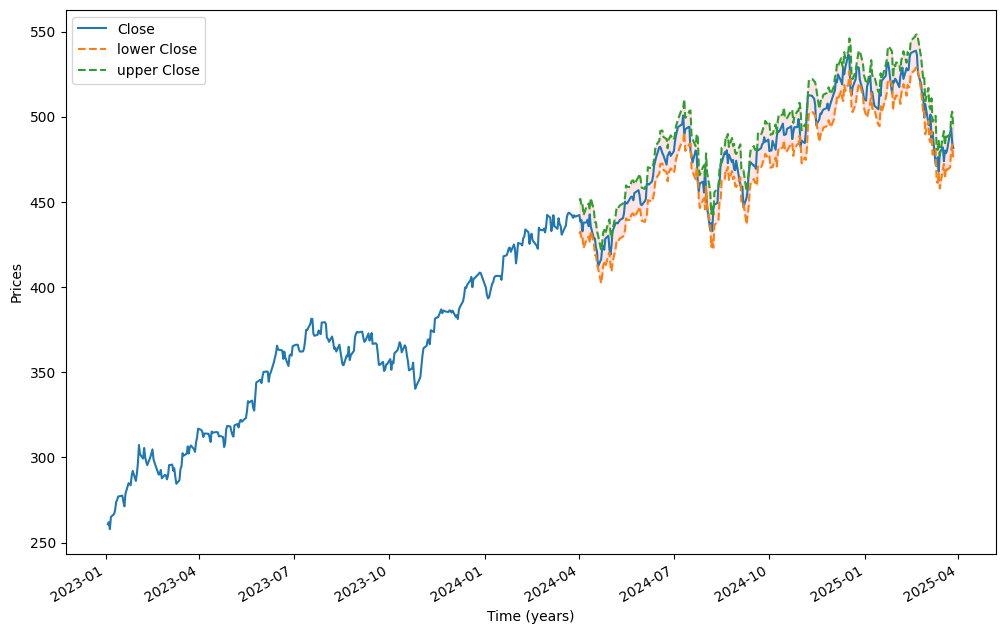

In [55]:
plt.figure(figsize=(12, 6))

ax = analysis['2023':].plot(label='actual')
prediction_ci.plot(
    ax=ax, style=['--', '--'],
    label='predicted/forecasted')

ci_index = prediction_ci.index
lower_ci = prediction_ci.iloc[:, 0]
upper_ci = prediction_ci.iloc[:, 1]

ax.fill_between(ci_index, lower_ci, upper_ci,
    color='r', alpha=.1)

ax.set_xlabel('Time (years)')
ax.set_ylabel('Prices')

plt.legend()
plt.show()